#### Bayesian Inference for Normal Mean

Given 1. **Likelihood**: Observations $X_1, \dots, X_n$ drawn from distribution $N(\theta, \sigma^2)$, with the mean $\theta$ unknown, and the variance $\sigma^2$ known. & 2. **Prior**: The unknown mean $\theta$ is assumed to follow a $N(a, b^2)$, where $a$ is the prior mean and $b^2$ is the prior variance.

- Derive the posterior distribution for $\theta$, and show that it follows Normal distribution.
- Explicitly show the derivation of the posterior mean $\hat{\theta}$ and posterior variance $\tau^2$ using **completing the square**.
- Simulate data from a Normal distribution with a known true mean ($\mu_{true}$) and standard deviation ($\sigma_{known}$).
- Compute (and plot) the posterior density for $\mu$ assuming an improper uniform prior $p(\mu) \propto 1$.
- Simulate draws from the posterior of $\mu$ and compare them with the analytical density.
- Compute the posterior density for a transformed parameter $\theta = e^\mu$** analytically (recognizing it as a Log-Normal distribution) and by simulation.
- Determine a 95% Bayesian Posterior (Credible) Interval for $\theta$ from the simulated draws.
- Determine a 95% Frequentist Confidence Interval for $\theta$ by transforming the confidence interval for $\mu$.
- Visualize the posterior density for $\theta$ with its 95% credible interval shaded, and compare it with the true value of $\theta = e^{\mu_{true}}$.

#### Bayesian Inference for Normal Mean with Known Variance and Normal Prior

Given the likelihood $X_1, \dots, X_n \sim N(\theta, \sigma^2)$ where $\sigma$ is known, and a prior $\theta \sim N(a, b^2)$, the posterior distribution for $\theta$ is also normal:

$\theta|X^n \sim N(\hat{\theta}, \tau^2)$

Where:
- $\hat{\theta} = w\bar{X} + (1-w)a$ is the posterior mean.
- $w = \frac{1/se^2}{1/se^2 + 1/b^2}$ is the weight given to the sample mean.
- $1/\tau^2 = 1/se^2 + 1/b^2$ is the inverse posterior variance.
- $se = \sigma/\sqrt{n}$ is the standard error of the MLE $\bar{X}$ (sample mean).

In [15]:
import numpy as np

# Assume some values for the parameters
# Likelihood parameters
sigma = 5.0   # Known standard deviation
n = 10        # Sample size
X_bar = 12.0  # Sample mean (MLE)

# Prior parameters
a = 10.0   # Prior mean
b = 2.0    # Prior standard deviation

# Calculate standard error of the MLE
se = sigma / np.sqrt(n)

# Calculate weight 'w'
w = (1 / se**2) / (1 / se**2 + 1 / b**2)

# Calculate posterior mean (theta_hat)
theta_hat = w * X_bar + (1 - w) * a

# Calculate inverse posterior variance (1/tau^2)
inv_tau_squared = 1 / se**2 + 1 / b**2
tau_squared = 1 / inv_tau_squared # Posterior variance

Standard Error (se): 1.5811
Weight (w): 0.6154
Posterior Mean (theta_hat): 11.2308
Posterior Variance (tau^2): 1.5385
Posterior Standard Deviation (tau): 1.2403


#### In general the Bayesian Inference for Normal Mean

Given 1. **Likelihood**: Observations $X_1, \dots, X_n$ drawn from distribution $N(\theta, \sigma^2)$, with the mean $\theta$ unknown, and the variance $\sigma^2$ known. & 2. **Prior**: The unknown mean $\theta$ is assumed to follow a $N(a, b^2)$, where $a$ is the prior mean and $b^2$ is the prior variance.


The posterior distribution $\theta|X_n$ is proportional to the product of the likelihood and prior: $p(\theta|X_n) \propto L(X_n|\theta)p(\theta)$

By focusing on the exponent of this product, we find:

$L(X^n|\theta)p(\theta) \propto \exp\left[-\frac{n}{2\sigma^2}(\theta - \bar{X})^2 - \frac{1}{2b^2}(\theta - a)^2\right]$

Completing the square on this exponent with respect to $\theta$ reveals that the posterior is also a normal distribution: $\theta|X^n \sim N(\hat{\theta}, \tau^2)$.

The derived posterior parameters are:
- **Posterior Precision (Inverse Variance):**
    $\frac{1}{\tau^2} = \frac{n}{\sigma^2} + \frac{1}{b^2}$
- **Posterior Mean:**
    $\hat{\theta} = \frac{\frac{n\bar{X}}{\sigma^2} + \frac{a}{b^2}}{\frac{n}{\sigma^2} + \frac{1}{b^2}} = \frac{n b^2 \bar{X} + a \sigma^2}{n b^2 + \sigma^2}$

Alternatively, the posterior mean can be expressed as a weighted average
$\hat{\theta} = w\bar{X} + (1-w)a$
where the weight given to the sample mean is:
$w = \frac{n/\sigma^2}{n/\sigma^2 + 1/b^2} = \frac{n b^2}{n b^2 + \sigma^2}$

#### Derivation of Posterior Mean and Variance by Completing the Square

We begin with the exponent of the unnormalized posterior distribution, which combines the likelihood and prior terms ${exponent} = -\frac{n}{2\sigma^2}(\theta - \bar{X})^2 - \frac{1}{2b^2}(\theta - a)^2$. Expand the quadratic terms and group terms by powers of $\theta$, $\text{exponent} = \theta^2 \left(-\frac{n}{2\sigma^2} - \frac{1}{2b^2}\right) + \theta \left(\frac{n\bar{X}}{\sigma^2} + \frac{a}{b^2}\right) + \text{constant terms}$

Let's define $A = -\frac{n}{2\sigma^2} - \frac{1}{2b^2} = -\frac{1}{2}\left(\frac{n}{\sigma^2} + \frac{1}{b^2}\right)$, and $B = \frac{n\bar{X}}{\sigma^2} + \frac{a}{b^2}$. So the exponent becomes $A\theta^2 + B\theta + C'$, where $C'$ represents terms not involving $\theta$. To complete the square, we want to express this in the form $A(\theta - \hat{\theta})^2 + \text{constant}$. Comparing $A\theta^2 + B\theta$ to $A(\theta - \hat{\theta})^2 = A(\theta^2 - 2\theta\hat{\theta} + \hat{\theta}^2) = A\theta^2 - 2A\hat{\theta}\theta + A\hat{\theta}^2$, we can equate coefficients for $\theta$: $B = -2A\hat{\theta}$

Solving for $\hat{\theta}$: $\hat{\theta} = -\frac{B}{2A}$. Substitute $A$ and $B$: $\hat{\theta} = \frac{\frac{n\bar{X}}{\sigma^2} + \frac{a}{b^2}}{\frac{n}{\sigma^2} + \frac{1}{b^2}}$. This is the posterior mean. To find the posterior variance, we recognize that the coefficient of $(\theta - \hat{\theta})^2$ in the completed square form of a Normal distribution is $-1/(2\tau^2)$. Thus: $A = -\frac{1}{2\tau^2}$. So, $\frac{1}{\tau^2} = -2A = \frac{n}{\sigma^2} + \frac{1}{b^2}$

This is the inverse posterior variance (precision). The posterior variance is  
- $\tau^2 = \left(\frac{n}{\sigma^2} + \frac{1}{b^2}\right)^{-1}$

#### Symbolic Derivation, completing the square for the Posterior Exponent

We start with the combined exponent of the likelihood and prior, expanded_exp_general, which is proportional to the log of the posterior. For the posterior to be a normal distribution, its exponent must be in the form of $-(1/(2\tau^2))(\theta - \hat{\theta})^2 + C$, where $C$ represents terms not dependent on $\theta$.

The general form for completing the square on an expression $A\theta^2 + B\theta + C'$ is $A(\theta + B/(2A))^2 + C' - B^2/(4A)$.

Here, $A = {coeff\_theta2\_general}$ and $B = {coeff\_theta\_general}$. We already found:
*   $\frac{1}{2\tau^2} = -A = -{coeff\_theta2\_general}$
*   $\hat{\theta} = -\frac{B}{2A} = -\frac{{coeff\_theta\_general}}{2 \cdot {coeff\_theta2\_general}}$

So, we expect the exponent to simplify to:
$A(\theta - \hat{\theta})^2 + \text{constant terms}$

Or, equivalently, using the inverse posterior variance:
$-\frac{1}{2\tau^2}(\theta - \hat{\theta})^2 + \text{constant terms}$

In [17]:
import sympy
from sympy import symbols

# Define symbolic variables, including a general n
theta, a, b, sigma, n = symbols('theta a b sigma n', positive=True)
X_bar = symbols('X_bar') # Sample mean

# Prior distribution N(a, b^2)
prior_exp = -((theta - a)**2) / (2 * b**2)

# Likelihood term involving theta for general n
likelihood_exp_general = -(n * (X_bar - theta)**2) / (2 * sigma**2)

# Product of likelihood and prior (ignoring constants for proportionality)
product_exp_general = likelihood_exp_general + prior_exp

# Expand the exponent
expanded_exp_general = sympy.expand(product_exp_general)

# Extract coefficients for theta^2 and theta (as done previously)
coeff_theta2_general = expanded_exp_general.coeff(theta, 2)
coeff_theta_general = expanded_exp_general.coeff(theta, 1)

print("Expanded exponent of the combined distribution:")
sympy.pprint(expanded_exp_general)

# Calculate the symbolic posterior mean and inverse posterior variance
# We know 1/(2*tau^2) = -coeff_theta2_general
inv_2_tau_squared_sym = sympy.simplify(-coeff_theta2_general)
posterior_tau_squared_sym = sympy.simplify(1 / (2 * inv_2_tau_squared_sym))

# We know posterior mean = -coeff_theta_general / (2 * coeff_theta2_general)
posterior_mean_sym = sympy.simplify(-coeff_theta_general / (2 * coeff_theta2_general))

# Reconstruct the quadratic part in completed square form: - (1/(2*tau^2)) * (theta - theta_hat)**2
quadratic_part_completed = -inv_2_tau_squared_sym * (theta - posterior_mean_sym)**2

# The constant part of the expanded_exp_general that does NOT contain theta
constant_part_original = expanded_exp_general.subs(theta, 0)

# The additional constant term generated from completing the square
# This is C_prime - B^2/(4A) in the general form A*theta^2 + B*theta + C_prime
# Here C_prime is constant_part_original.
# B/(2A) is -posterior_mean_sym.
# The term we subtract is -coeff_theta2_general * (posterior_mean_sym)**2
# So the final constant term in the completed square form is:
constant_term_completed = sympy.simplify(constant_part_original - coeff_theta2_general * (posterior_mean_sym)**2)

# Combine the completed quadratic part and the constant term
full_completed_square_expression = quadratic_part_completed + constant_term_completed

print("\nFull exponent in completed square form:")
sympy.pprint(full_completed_square_expression)

print(f"\nThis clearly shows the form -1/(2*tau^2)*(theta - theta_hat)^2 + C")
print(f"where -1/(2*tau^2) = {sympy.simplify(coeff_theta2_general)}")
print(f"and theta_hat = {sympy.simplify(posterior_mean_sym)}")

# Verify that the reconstructed form is equivalent to the original expanded form
if sympy.simplify(full_completed_square_expression - expanded_exp_general) == 0:
    print("\nVerification: The reconstructed completed square form matches the original expanded exponent.")
else:
    print("\nError: The reconstructed completed square form DOES NOT match the original expanded exponent.")
    sympy.pprint(sympy.simplify(full_completed_square_expression - expanded_exp_general))


Expanded exponent of the combined distribution:
       2                   2             2     2 
  X_bar ⋅n   X_bar⋅n⋅θ    a     a⋅θ   n⋅θ     θ  
- ──────── + ───────── - ──── + ─── - ──── - ────
       2         2          2    2       2      2
    2⋅σ         σ        2⋅b    b     2⋅σ    2⋅b 

Full exponent in completed square form:
                                                       2                
  ⎛       2                2⎞   ⎛           2        2⎞                 
n⋅⎝- X_bar  + 2⋅X_bar⋅a - a ⎠   ⎜    X_bar⋅b ⋅n + a⋅σ ⎟  ⎛   n      1  ⎞
───────────────────────────── + ⎜θ - ─────────────────⎟ ⋅⎜- ──── - ────⎟
          ⎛ 2      2⎞           ⎜         2      2    ⎟  ⎜     2      2⎟
        2⋅⎝b ⋅n + σ ⎠           ⎝        b ⋅n + σ     ⎠  ⎝  2⋅σ    2⋅b ⎠

This clearly shows the form -1/(2*tau^2)*(theta - theta_hat)^2 + C
where -1/(2*tau^2) = -n/(2*sigma**2) - 1/(2*b**2)
and theta_hat = (X_bar*b**2*n + a*sigma**2)/(b**2*n + sigma**2)

Verification: The reconstructed complete

We can generalize the symbolic derivation to verify the posterior mean and variance formulas for any $n$. The key idea is to recognize that the likelihood term involving $\theta$ is proportional to $e^{-\frac{n}{2\sigma^2}(\theta - \bar{X})^2}$. We will use this general form in sympy and compare the derived posterior parameters with the established formulas.

In [16]:
import sympy
from sympy import symbols, exp, sqrt, pi

# Define symbolic variables, including a general n
theta, a, b, sigma, n = symbols('theta a b sigma n', positive=True)
X_bar = symbols('X_bar') # Sample mean
# Prior distribution N(a, b^2)
prior_exp = -((theta - a)**2) / (2 * b**2)
# Likelihood term involving theta for general n
# L(X^n|theta) is proportional to exp(-(n * (X_bar - theta)**2) / (2*sigma**2))
likelihood_exp_general = -(n * (X_bar - theta)**2) / (2 * sigma**2)
# Product of likelihood and prior (ignoring constants for proportionality)
product_exp_general = likelihood_exp_general + prior_exp
# Simplify and EXPAND the exponent to correctly extract coefficients
expanded_exp_general = sympy.expand(product_exp_general)
print("Expanded exponent of the combined distribution for general n:")
sympy.pprint(expanded_exp_general)

# Extract coefficients for theta^2 and theta
coeff_theta2_general = expanded_exp_general.coeff(theta, 2)
coeff_theta_general = expanded_exp_general.coeff(theta, 1)

print(f"\nCoefficient of theta^2 (general n): {coeff_theta2_general}")
print(f"Coefficient of theta (general n): {coeff_theta_general}")

# Derive tau^2 symbolically for general n
tau_squared_sym_general = -1 / (2 * coeff_theta2_general)
# Derive theta_hat symbolically for general n
theta_hat_sym_general = coeff_theta_general * tau_squared_sym_general

print(f"\nSymbolic Posterior Variance (tau^2) for general n: {sympy.simplify(tau_squared_sym_general)}")
print(f"Symbolic Posterior Mean (theta_hat) for general n: {sympy.simplify(theta_hat_sym_general)}")

# Compare these with the general formulas previously defined:
# 1/tau^2 = 1/se^2 + 1/b^2 = n/sigma^2 + 1/b^2
# w = (1/se^2) / (1/se^2 + 1/b^2) = (n/sigma^2) / (n/sigma^2 + 1/b**2)
# theta_hat = w * X_bar + (1 - w) * a

# Expected 1/tau^2 = n/sigma**2 + 1/b**2
expected_inv_tau_squared_formula_general = n/sigma**2 + 1/b**2
expected_tau_squared_formula_general = 1 / expected_inv_tau_squared_formula_general

print(f"\nExpected tau^2 from general formula: {sympy.simplify(expected_tau_squared_formula_general)}")

# Compare the derived tau^2_sym_general with expected_tau_squared_formula_general
if sympy.simplify(tau_squared_sym_general - expected_tau_squared_formula_general) == 0:
    print("Symbolic tau^2 for general n matches the formula!")
else:
    print("Symbolic tau^2 for general n DOES NOT match the formula. Check derivation.")

# Expected theta_hat formula for general n
expected_w_general = (n/sigma**2) / (n/sigma**2 + 1/b**2)
expected_theta_hat_formula_general = sympy.simplify(expected_w_general * X_bar + (1 - expected_w_general) * a)

print(f"\nExpected theta_hat from general formula: {sympy.simplify(expected_theta_hat_formula_general)}")

# Compare the derived theta_hat_sym_general with expected_theta_hat_formula_general
if sympy.simplify(theta_hat_sym_general - expected_theta_hat_formula_general) == 0:
    print("Symbolic theta_hat for general n matches the formula!")
else:
    print("Symbolic theta_hat for general n DOES NOT match the formula. Check derivation.")

Expanded exponent of the combined distribution for general n:
       2                   2             2     2 
  X_bar ⋅n   X_bar⋅n⋅θ    a     a⋅θ   n⋅θ     θ  
- ──────── + ───────── - ──── + ─── - ──── - ────
       2         2          2    2       2      2
    2⋅σ         σ        2⋅b    b     2⋅σ    2⋅b 

Coefficient of theta^2 (general n): -n/(2*sigma**2) - 1/(2*b**2)
Coefficient of theta (general n): X_bar*n/sigma**2 + a/b**2

Symbolic Posterior Variance (tau^2) for general n: b**2*sigma**2/(b**2*n + sigma**2)
Symbolic Posterior Mean (theta_hat) for general n: (X_bar*b**2*n + a*sigma**2)/(b**2*n + sigma**2)

Expected tau^2 from general formula: b**2*sigma**2/(b**2*n + sigma**2)
Symbolic tau^2 for general n matches the formula!

Expected theta_hat from general formula: (X_bar*b**2*n + a*sigma**2)/(b**2*n + sigma**2)
Symbolic theta_hat for general n matches the formula!


#### Simulate Data and Compute Posterior Density for $\mu$

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Simulate a dataset
np.random.seed(42) # for reproducibility
mu_true = 5        # True mean
n_obs = 100        # Number of observations

data = np.random.normal(loc=mu_true, scale=1, size=n_obs)

print(f"Simulated {n_obs} observations from N(mu={mu_true}, sigma=1). \n"
f"Sample mean (X_bar): {np.mean(data):.4f} \n"
f"Sample standard deviation: {np.std(data):.4f}")


Simulated 100 observations from N(mu=5, sigma=1).
Sample mean (X_bar): 4.8962
Sample standard deviation: 0.9036


#### Compute the Posterior Density for $\mu$ (Constant Prior)

Given $X_i \sim N(\mu, \sigma^2)$ where $\sigma=1$ is known, and an improper uniform prior $p(\mu) \propto 1$, the posterior distribution for $\mu$ is:

$\mu | X^n \sim N(\bar{X}, \sigma^2/n)$

In our case, $\sigma^2 = 1$, so $\mu | X^n \sim N(\bar{X}, 1/n)$.


Posterior Mean (mu_hat): 4.8962
Posterior Variance: 0.0100
Posterior Standard Deviation: 0.1000


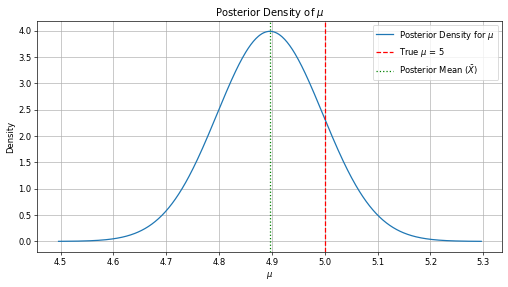

In [19]:
# Calculate posterior parameters
sample_mean = np.mean(data)
posterior_variance_mu = 1 / n_obs
posterior_std_mu = np.sqrt(posterior_variance_mu)

print(f"Posterior Mean (mu_hat): {sample_mean:.4f} \n"
f"Posterior Variance: {posterior_variance_mu:.4f} \n"
f"Posterior Standard Deviation: {posterior_std_mu:.4f}")

# Plot the posterior density
plt.figure(figsize=(10, 5), dpi=60)
mu_values = np.linspace(sample_mean - 4*posterior_std_mu, sample_mean + 4*posterior_std_mu, 500)
posterior_density_mu = stats.norm.pdf(mu_values, loc=sample_mean, scale=posterior_std_mu)

plt.plot(mu_values, posterior_density_mu, label=r'Posterior Density for $\mu$')
plt.axvline(x=mu_true, color='r', linestyle='--', label=r'True $\mu$ = 5')
plt.axvline(x=sample_mean, color='g', linestyle=':', label=r'Posterior Mean ($\bar{X}$)')
plt.title(r'Posterior Density of $\mu$')
plt.xlabel(r'$\mu$') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### Simulate 1000 Draws from the Posterior and Compare

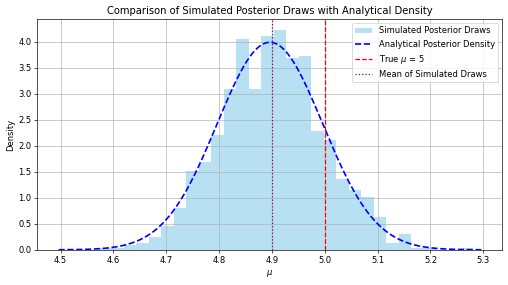

In [20]:
# Simulate 1000 draws from the posterior
num_draws = 1000
posterior_draws_mu = np.random.normal(loc=sample_mean, scale=posterior_std_mu, size=num_draws)

# Plot histogram of draws and compare with density
plt.figure(figsize=(10, 5), dpi=60)
plt.hist(posterior_draws_mu, bins=30, density=True, alpha=0.6, color='skyblue', label='Simulated Posterior Draws')
plt.plot(mu_values, posterior_density_mu, color='blue', linestyle='--', linewidth=2, label='Analytical Posterior Density')

plt.axvline(x=mu_true, color='r', linestyle='--', label=r'True $\mu$ = 5')
plt.axvline(x=np.mean(posterior_draws_mu), color='purple', linestyle=':', label='Mean of Simulated Draws')
plt.title('Comparison of Simulated Posterior Draws with Analytical Density')
plt.xlabel(r'$\mu$') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### Compute the Posterior Density for $\theta = e^\mu$ Analytically and by Simulation

Given that the posterior distribution for $\mu$ is $\mu | X^n \sim N(\bar{X}, 1/n)$, and we are interested in $\theta = e^\mu$, $\theta$ will follow a Log-Normal distribution. If $Y \sim N(\text{mean}, \text{variance})$, then $e^Y \sim \text{LogNormal}(\text{mean}, \text{variance})$, where the parameters of the Log-Normal distribution are the mean and variance of the underlying Normal distribution.

Thus, the posterior for $\theta$ is $\theta | X^n \sim \text{Log-Normal}(\bar{X}, 1/n)$.

Log-Normal parameters for theta: s=0.1000, scale=133.7742


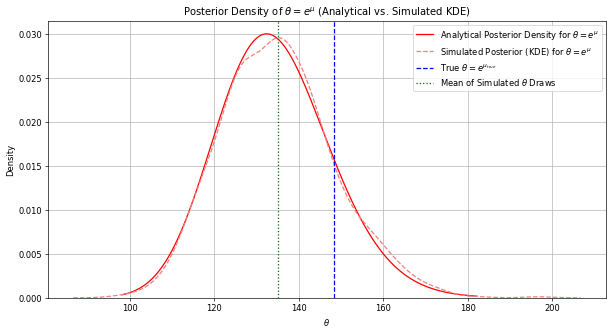

In [21]:
import seaborn as sns
# Analytical Posterior for theta = exp(mu)
# Since mu ~ N(posterior_mean_mu, posterior_variance_mu),
# theta = exp(mu) ~ LogNormal(posterior_mean_mu, posterior_variance_mu)

# The parameters for the Log-Normal distribution are the mean and variance of the underlying normal distribution
lognorm_s = posterior_std_mu # This is the standard deviation of the underlying normal distribution
lognorm_loc = 0 # The 'loc' parameter for scipy.stats.lognorm is a shift, which is 0 for exp(Normal)
lognorm_scale = np.exp(sample_mean) # This is exp(mean) of the underlying normal distribution

print(f"Log-Normal parameters for theta: s={lognorm_s:.4f}, scale={lognorm_scale:.4f}")

# Generate values for theta to plot the density
theta_values_analytical = np.linspace(stats.lognorm.ppf(0.001, s=lognorm_s, scale=lognorm_scale), stats.lognorm.ppf(0.999, s=lognorm_s, scale=lognorm_scale), 500)

posterior_density_theta_analytical = stats.lognorm.pdf(theta_values_analytical, s=lognorm_s, scale=lognorm_scale)

# Simulation for theta = exp(mu)
posterior_draws_theta_simulated = np.exp(posterior_draws_mu)

# Plotting
plt.figure(figsize=(12, 6), dpi=60)

# Plot Analytical Posterior for Theta
plt.plot(theta_values_analytical, posterior_density_theta_analytical, color='red', linestyle='-', label=r'Analytical Posterior Density for $\theta = e^\mu$')

# Plot Simulated Posterior for Theta using KDE
sns.kdeplot(posterior_draws_theta_simulated, color='lightcoral', linestyle='--', label=r'Simulated Posterior (KDE) for $\theta = e^\mu$')

plt.axvline(x=np.exp(mu_true), color='blue', linestyle='--', label=r'True $\theta = e^{\mu_{true}}$')
plt.axvline(x=np.mean(posterior_draws_theta_simulated), color='darkgreen', linestyle=':', label=r'Mean of Simulated $\theta$ Draws')
plt.title(r'Posterior Density of $\theta = e^\mu$ Analytical vs. Simulated KDE')
plt.xlabel(r'$\theta$') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### 95% Posterior Interval for $\theta$
A Bayesian posterior interval (often called a credible interval) for $\theta$ is directly obtained from the quantiles of its posterior distribution. We can use the simulated posterior draws of $\theta$ to find the 2.5th and 97.5th percentiles, which will define a 95% equal-tailed credible interval.

#### 95% Confidence Interval for $\theta$

A frequentist confidence interval for $\theta = e^\mu$ is derived from the confidence interval of $\mu$. Since $X_i \sim N(\mu, \sigma^2)$ with known $\sigma$, the 95% confidence interval for $\mu$ is given by $[\bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}}]$, where $z_{\alpha/2}$ is the critical value from the standard normal distribution (e.g., 1.96 for a 95% CI).

Given $\sigma=1$ and $n=100$, this simplifies to $[\bar{X} - 1.96 \frac{1}{\sqrt{100}}, \bar{X} + 1.96 \frac{1}{\sqrt{100}}] = [\bar{X} - 0.196, \bar{X} + 0.196]$

To find the 95% confidence interval for $\theta = e^\mu$, we simply exponentiate the bounds of the confidence interval for $\mu$ $[e^{\bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}}, e^{\bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}}}]$

It's important to note that while the posterior interval directly describes the probability of $\theta$ falling within the interval given the data, the confidence interval describes the long-run frequency with which such intervals, if constructed repeatedly from many samples, would contain the true value of $\theta$.

In [22]:
# 95% Posterior Interval for theta (from simulated draws)
posterior_interval_theta = np.percentile(posterior_draws_theta_simulated, [2.5, 97.5])

# 95% Frequentist Confidence Interval for theta
alpha = 0.05
z_alpha_half = stats.norm.ppf(1 - alpha/2) # For 95% CI, z_alpha_half is ~1.96

# Standard error of the mean for mu
std_err_mu = 1 / np.sqrt(n_obs) # sigma = 1 is known

# 95% CI for mu
ci_mu_lower = sample_mean - z_alpha_half * std_err_mu
ci_mu_upper = sample_mean + z_alpha_half * std_err_mu

# Transform to 95% CI for theta = exp(mu)
ci_theta_lower = np.exp(ci_mu_lower) ; ci_theta_upper = np.exp(ci_mu_upper)

95% Posterior (Credible) Interval for theta: [111.9683, 164.3938]

95% Confidence Interval for mu: [4.7002, 5.0921]
95% Confidence Interval for theta (transformed from mu): [109.9644, 162.7394]

--- Summary for theta ---
True mu: 5
True theta (exp(mu)): 148.4132
Posterior Mean of mu: 4.8962
Mean of simulated theta draws: 135.0397
95% Posterior Interval for theta: [111.9683, 164.3938]
95% Confidence Interval for theta: [109.9644, 162.7394]


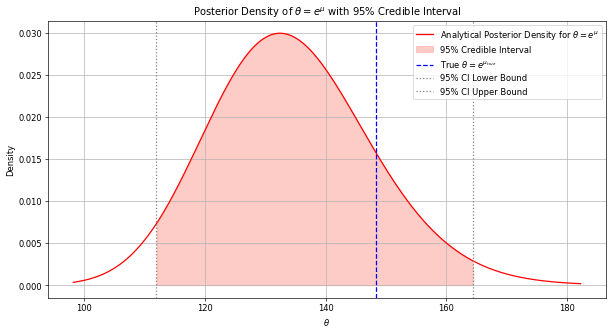

In [23]:
plt.figure(figsize=(12, 6), dpi=60)

# Plot Analytical Posterior for Theta
plt.plot(theta_values_analytical, posterior_density_theta_analytical, color='red', linestyle='-', label=r'Analytical Posterior Density for $\theta = e^\mu$')

# Shade the 95% Posterior Interval
plt.fill_between(theta_values_analytical,
                 0,
                 posterior_density_theta_analytical,
                 where=(theta_values_analytical >= posterior_interval_theta[0]) & (theta_values_analytical <= posterior_interval_theta[1]),
                 color='salmon', alpha=0.4, label='95% Credible Interval')

plt.axvline(x=np.exp(mu_true), color='blue', linestyle='--', label=r'True $\theta = e^{\mu_{true}}$')
plt.axvline(x=posterior_interval_theta[0], color='gray', linestyle=':', label='95% CI Lower Bound')
plt.axvline(x=posterior_interval_theta[1], color='gray', linestyle=':', label='95% CI Upper Bound')

plt.title(r'Posterior Density of $\theta = e^\mu$ with 95% Credible Interval')
plt.xlabel(r'$\theta$') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### Bayesian Inference for Uniform variance

Given observations $X_1, \dots, X_n \sim \text{Uniform}(0, \theta)$, where $\theta$ is unknown. The likelihood function is:

$L(X^n|\theta) = \frac{1}{\theta^n} \mathbb{I}(0 < X_{(1)}, \dots, X_{(n)} < \theta)$ or $L(X^n|\theta) = \frac{1}{\theta^n} \mathbb{I}(X_{(n)} < \theta)$ where $X_{(n)}$ is the maximum order statistic.

Given the prior density $p(\theta) \propto \frac{1}{\theta}$ for $\theta > 0$.

We need to compute the posterior distribution $p(\theta|X^n) \propto L(X^n|\theta)p(\theta)$.
- $p(\theta|X^n) \propto \frac{1}{\theta^n} \cdot \frac{1}{\theta} \cdot \mathbb{I}(X_{(n)} < \theta)$, $p(\theta|X^n) \propto \frac{1}{\theta^{n+1}} \mathbb{I}(X_{(n)} < \theta)$

The posterior distribution for $\theta$ given the observations $X^n$ is:

$p(\theta|X^n) = \frac{n X_{(n)}^n}{\theta^{n+1}} \mathbb{I}(X_{(n)} < \theta)$

This is a **Pareto distribution** with parameters $X_{(n)}$ (scale) and $n$ (shape).

#### Derivation of Posterior Distribution for Uniform Likelihood with Inverse Prior

Given the likelihood $L(X^n|\theta) = \frac{1}{\theta^n} \mathbb{I}(X_{(n)} < \theta)$ where $X_{(n)}$ is the maximum order statistic, and the prior $p(\theta) \propto \frac{1}{\theta}$ for $\theta > 0$.

The posterior distribution is proportional to the product of the likelihood and the prior: $p(\theta|X^n) \propto L(X^n|\theta) p(\theta)$. Substitute the given likelihood and prior: $p(\theta|X^n) \propto \left(\frac{1}{\theta^n} \mathbb{I}(X_{(n)} < \theta)\right) \cdot \left(\frac{1}{\theta}\right)$. Combine the terms involving $\theta$: $p(\theta|X^n) \propto \frac{1}{\theta^{n+1}} \mathbb{I}(X_{(n)} < \theta)$.

To find the normalized posterior distribution, we need to integrate the unnormalized posterior over its support, which is from $X_{(n)}$ to $\infty$, since $\theta$ must be greater than $X_{(n)}$. Let the normalizing constant be $K$. Then: $\frac{1}{K} = \int_{X_{(n)}}^{\infty} \frac{1}{\theta^{n+1}} d\theta$.

To evaluate this integral, we use the power rule for integration $\int x^m dx = \frac{x^{m+1}}{m+1}$: $\frac{1}{K} = \left[\frac{\theta^{-(n+1)+1}}{-(n+1)+1}\right]_{X_{(n)}}^{\infty} = \left[\frac{\theta^{-n}}{-n}\right]_{X_{(n)}}^{\infty}$.

Assuming $n > 0$ (which is true for a sample size)
- $\frac{1}{K} = \left( \lim_{\theta \to \infty} \frac{\theta^{-n}}{-n} \right) - \left( \frac{X_{(n)}^{-n}}{-n} \right)$

As $\theta \to \infty$, $\theta^{-n} \to 0$. So: $\frac{1}{K} = 0 - \left( -\frac{X_{(n)}^{-n}}{n} \right) = \frac{X_{(n)}^{-n}}{n}$.

Therefore, the normalizing constant $K$ is: $K = \frac{n}{X_{(n)}^{-n}} = n X_{(n)}^n$.

Now, we can write the full posterior distribution by multiplying the unnormalized posterior by the normalizing constant $K$: $p(\theta|X^n) = K \cdot \frac{1}{\theta^{n+1}} \mathbb{I}(X_{(n)} < \theta)$, $p(\theta|X^n) = \frac{n X_{(n)}^n}{\theta^{n+1}} \mathbb{I}(X_{(n)} < \theta)$

This is the probability density function of a **Pareto distribution** with scale parameter $X_{(n)}$ and shape parameter $n$.